Found 10 files in ../data/2
Found 12 files in ../data/5


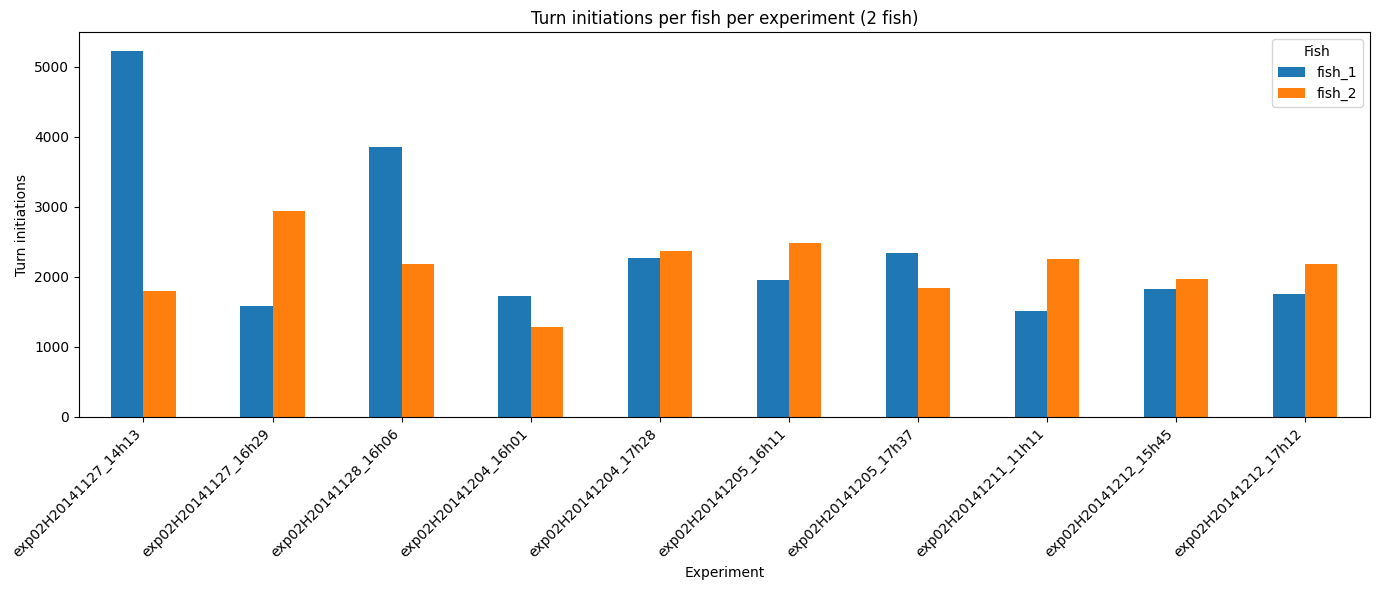

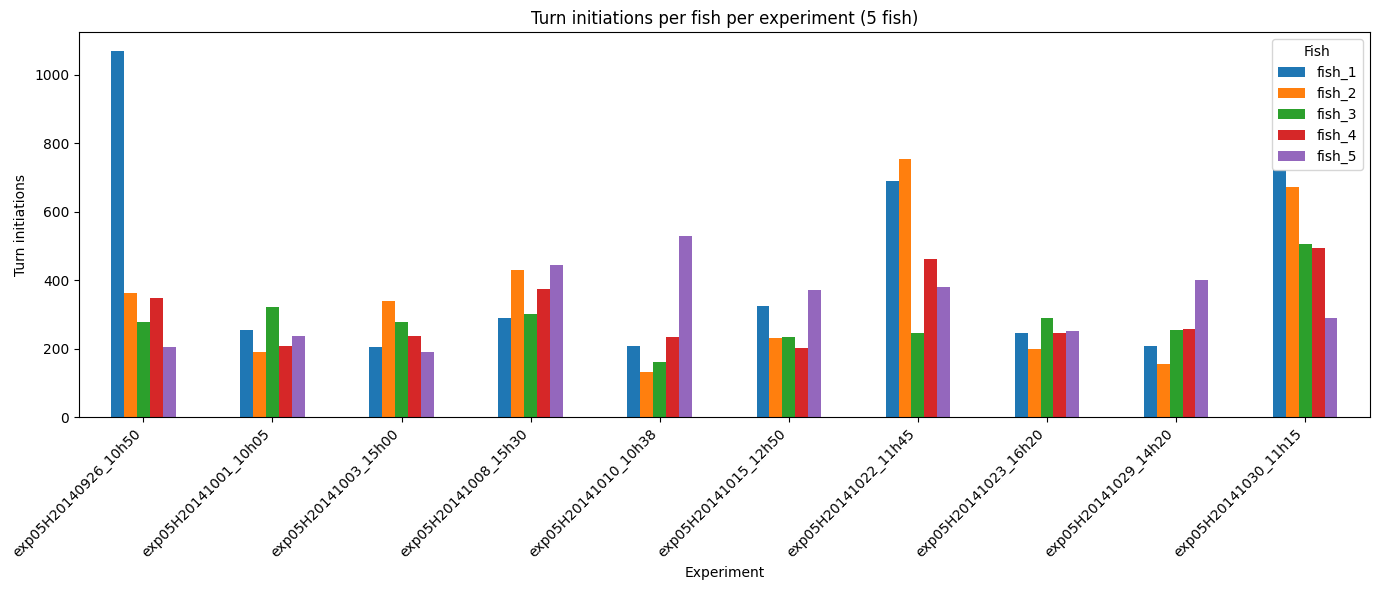

In [6]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_turning_points(x: np.typing.NDArray, y: np.typing.NDArray,
                        threshold_deg=45, min_frames=5) -> list[tuple[int, int]]:
    '''
    Detect sharp, sustained direction changes in fish movement.
    '''
    dx = np.diff(x)
    dy = np.diff(y)
    theta = np.arctan2(dy, dx)

    # smooth theta slightly to remove per-frame wobble
    from scipy.ndimage import uniform_filter1d
    theta = uniform_filter1d(theta, size=5)

    raw_diff = theta[1:] - theta[:-1]
    diff = (raw_diff + np.pi) % (2 * np.pi) - np.pi

    threshold = np.deg2rad(threshold_deg)
    turn_arounds = []

    i = 0
    while i < len(diff) - min_frames:
        # cumulative angle change over min_frames
        cumulative = np.sum(diff[i:i + min_frames])
        if np.abs(cumulative) > threshold:
            turn_arounds.append((i, i + 1))
            i += min_frames  # skip forward to avoid double counting
        else:
            i += 1

    return turn_arounds

def get_continuous_chunks(df, n_fish):
    columns = [f'X{i}' for i in range(1, n_fish+1)] + \
              [f'Y{i}' for i in range(1, n_fish+1)] + \
              [f'H{i}' for i in range(1, n_fish+1)]
    df = df[columns].copy()
    valid = df.notna().all(axis=1)
    chunk_id = (valid != valid.shift()).cumsum()
    chunks = []
    for cid, chunk in df.groupby(chunk_id):
        if chunk.notna().all(axis=None):
            chunk = chunk.reset_index(drop=True)
            chunk['timestep'] = range(len(chunk))
            chunks.append(chunk)
    return chunks

def data_access(folder, n_fish, initiation_window):
    files = sorted(glob.glob(f'{folder}/*.csv'))
    print(f'Found {len(files)} files in {folder}')

    exp_chunks = {}
    exp_initiations = {}

    for f in files:
        if not os.path.basename(f).startswith('exp'):
            continue
        df = pd.read_csv(f)
        exp_id = os.path.basename(f).replace('.csv', '')
        exp_chunks[exp_id] = []
        initiation_counts = {f'fish_{i}': 0 for i in range(1, n_fish+1)}

        for chunk in get_continuous_chunks(df, n_fish):
            chunk['exp_id'] = exp_id
            exp_chunks[exp_id].append(chunk)

            fish_turns = {}
            for i in range(1, n_fish + 1):
                x = chunk[f'X{i}'].values
                y = chunk[f'Y{i}'].values
                turns = find_turning_points(x, y)
                fish_turns[i] = set(t[0] for t in turns)

            for i in range(1, n_fish + 1):
                for t in fish_turns[i]:
                    others_turned_recently = any(
                        any(t - initiation_window <= t2 < t for t2 in fish_turns[j])
                        for j in range(1, n_fish + 1) if j != i
                    )
                    if not others_turned_recently:
                        initiation_counts[f'fish_{i}'] += 1

        exp_initiations[exp_id] = initiation_counts

    summary_df = pd.DataFrame(exp_initiations).T
    summary_df.index.name = 'exp_id'
    return exp_chunks, summary_df


def plot_initiations(summary_df, title):
    ax = summary_df.plot(kind='bar', figsize=(14, 6))
    plt.title(title)
    plt.xlabel('Experiment')
    plt.ylabel('Turn initiations')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Fish')
    plt.tight_layout()
    plt.show()


# Run for both 2 and 5 fish
_, summary_2 = data_access(folder='../data/2', n_fish=2, initiation_window=15)
_, summary_5 = data_access(folder='../data/5', n_fish=5, initiation_window=15)

plot_initiations(summary_2, title='Turn initiations per fish per experiment (2 fish)')
plot_initiations(summary_5, title='Turn initiations per fish per experiment (5 fish)')

Found 10 files in ../data/2
exp02H20141127_14h13: 5 chunks, 69.2 min clean tracking
exp02H20141127_16h29: 4 chunks, 63.3 min clean tracking
exp02H20141128_16h06: 10 chunks, 77.2 min clean tracking
exp02H20141204_16h01: 7 chunks, 55.9 min clean tracking
exp02H20141204_17h28: 3 chunks, 68.4 min clean tracking
exp02H20141205_16h11: 4 chunks, 86.2 min clean tracking
exp02H20141205_17h37: 13 chunks, 53.5 min clean tracking
exp02H20141211_11h11: 3 chunks, 53.2 min clean tracking
exp02H20141212_15h45: 4 chunks, 54.5 min clean tracking
exp02H20141212_17h12: 1 chunks, 66.1 min clean tracking
Found 12 files in ../data/5
exp05H20140926_10h50: 31 chunks, 49.5 min clean tracking
exp05H20141001_10h05: 26 chunks, 48.2 min clean tracking
exp05H20141003_15h00: 29 chunks, 59.3 min clean tracking
exp05H20141008_15h30: 31 chunks, 47.7 min clean tracking
exp05H20141010_10h38: 33 chunks, 48.8 min clean tracking
exp05H20141015_12h50: 28 chunks, 50.5 min clean tracking
exp05H20141022_11h45: 29 chunks, 44.2 mi

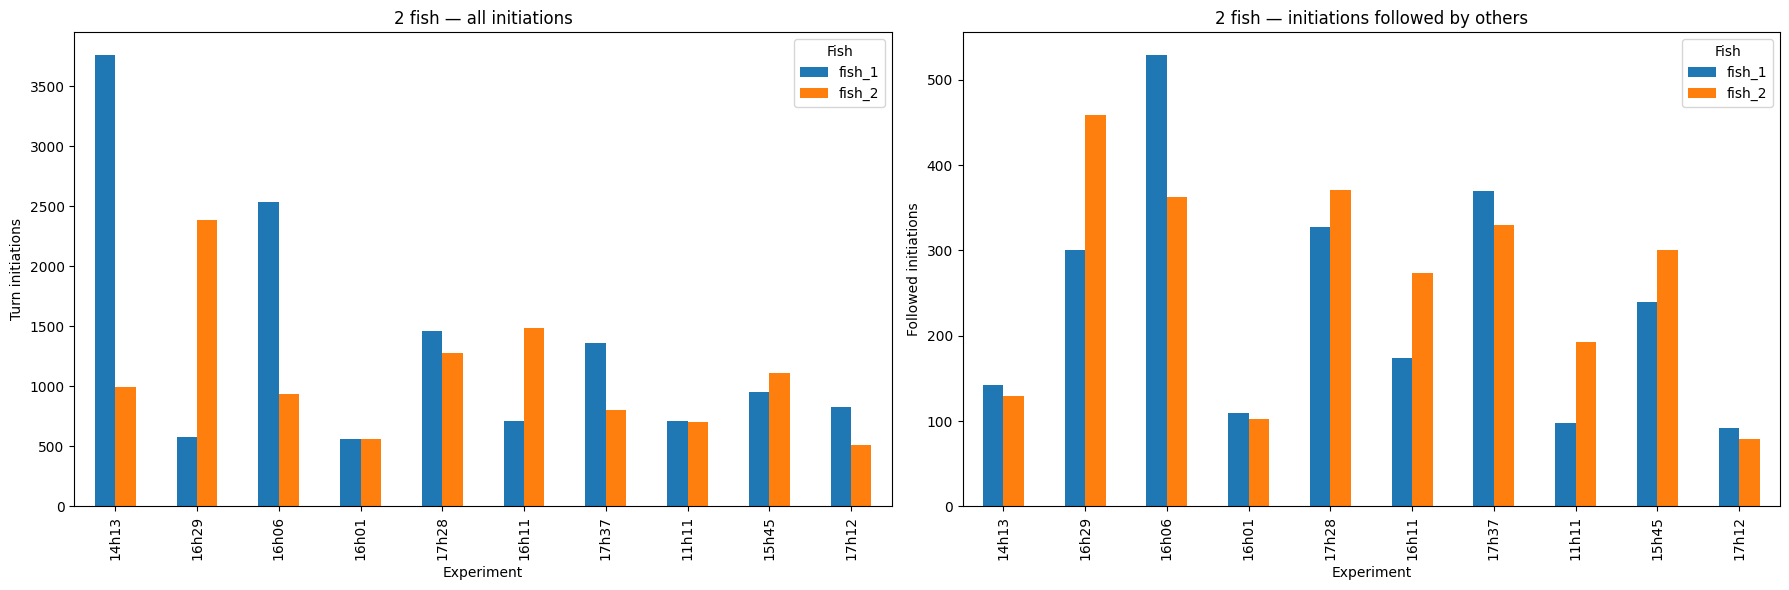

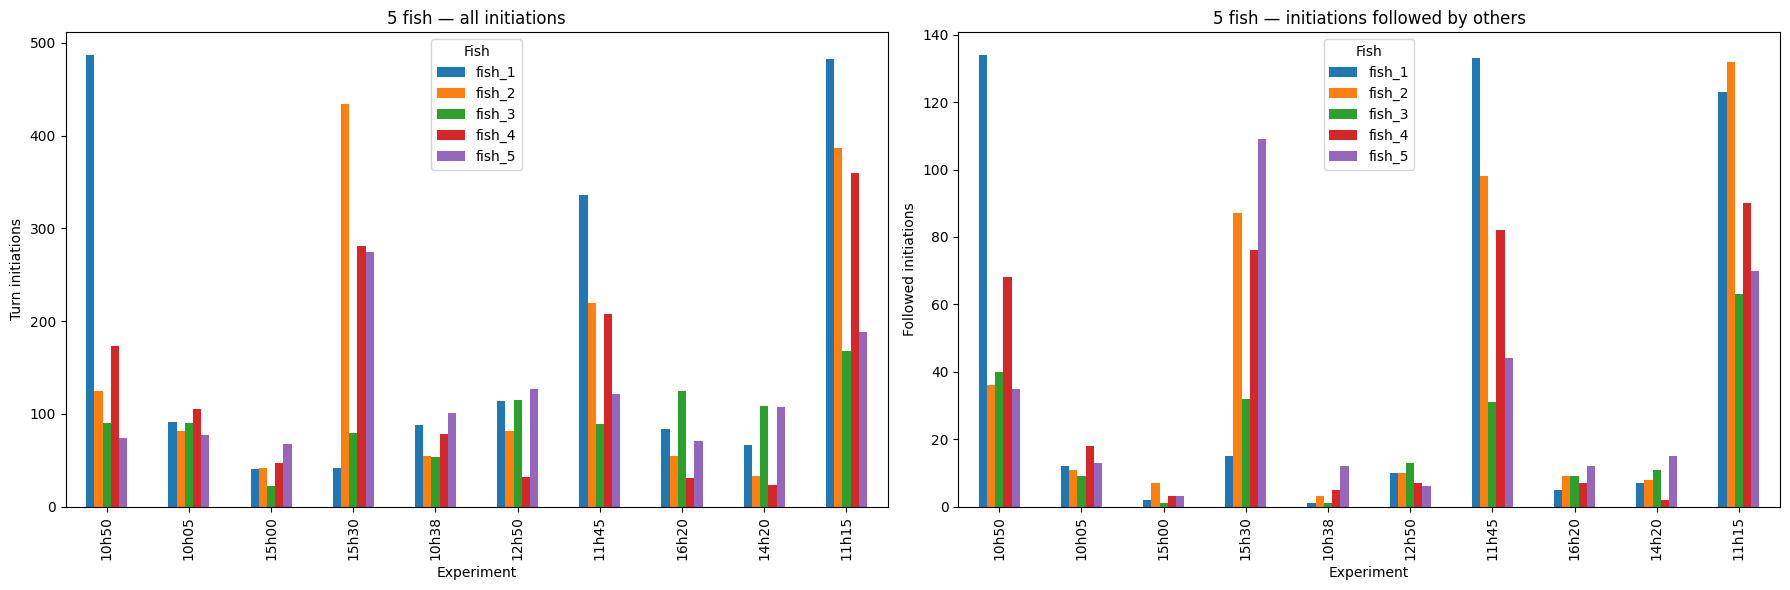

In [24]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_turning_points(x: np.typing.NDArray, y: np.typing.NDArray, threshold_deg=90, min_frames=10) -> list[tuple[int, int]]:
    dx = np.diff(x)
    dy = np.diff(y)
    theta = np.arctan2(dy, dx)

    raw_diff = theta[1:] - theta[:-1]
    diff = (raw_diff + np.pi) % (2 * np.pi) - np.pi

    threshold = np.deg2rad(threshold_deg)
    turn_arounds = []
    i = 0
    while i < len(diff) - min_frames:
        cumulative = np.sum(diff[i:i + min_frames])
        if np.abs(cumulative) > threshold:
            turn_arounds.append((i, i + 1))
            i += min_frames
        else:
            i += 1
    return turn_arounds

def get_continuous_chunks(df, n_fish, min_chunk_frames=50*30):
    columns = [f'X{i}' for i in range(1, n_fish+1)] + \
              [f'Y{i}' for i in range(1, n_fish+1)] + \
              [f'H{i}' for i in range(1, n_fish+1)]
    df = df[columns].copy()
    valid = df.notna().all(axis=1)
    chunk_id = (valid != valid.shift()).cumsum()
    chunks = []
    for cid, chunk in df.groupby(chunk_id):
        if chunk.notna().all(axis=None) and len(chunk) >= min_chunk_frames:
            chunk = chunk.reset_index(drop=True)
            chunk['timestep'] = range(len(chunk))
            chunks.append(chunk)
    return chunks

def data_access(folder, n_fish, initiation_window, follow_distance_mm=100):
    files = sorted(glob.glob(f'{folder}/*.csv'))
    print(f'Found {len(files)} files in {folder}')

    exp_chunks = {}
    exp_initiations = {}
    exp_followed = {}

    for f in files:
        if not os.path.basename(f).startswith('exp'):
            continue
        df = pd.read_csv(f)
        exp_id = os.path.basename(f).replace('.csv', '')
        exp_chunks[exp_id] = []
        initiation_counts = {f'fish_{i}': 0 for i in range(1, n_fish+1)}
        followed_counts = {f'fish_{i}': 0 for i in range(1, n_fish+1)}

        for chunk in get_continuous_chunks(df, n_fish):
            chunk['exp_id'] = exp_id
            exp_chunks[exp_id].append(chunk)

            fish_turns = {}
            for i in range(1, n_fish + 1):
                x = chunk[f'X{i}'].values
                y = chunk[f'Y{i}'].values
                turns = find_turning_points(x, y)
                fish_turns[i] = set(t[0] for t in turns)

            for i in range(1, n_fish + 1):
                for t in fish_turns[i]:
                    others_turned_before = any(
                        any(t - initiation_window <= t2 < t for t2 in fish_turns[j])
                        for j in range(1, n_fish + 1) if j != i
                    )
                    if not others_turned_before:
                        initiation_counts[f'fish_{i}'] += 1

                        # position of initiator at time t
                        ix = chunk[f'X{i}'].iloc[t]
                        iy = chunk[f'Y{i}'].iloc[t]

                        followers = []
                        for j in range(1, n_fish + 1):
                            if j == i:
                                continue

                            # distance between i and j at time t
                            jx = chunk[f'X{j}'].iloc[t]
                            jy = chunk[f'Y{j}'].iloc[t]
                            dist = np.sqrt((ix - jx)**2 + (iy - jy)**2)

                            if dist > follow_distance_mm:
                                continue  # too far away, skip

                            # turned within window
                            if any(t < t2 <= t + initiation_window for t2 in fish_turns[j]):
                                followers.append(j)

                        if followers:
                            followed_counts[f'fish_{i}'] += 1

        exp_initiations[exp_id] = initiation_counts
        exp_followed[exp_id] = followed_counts

    summary_df = pd.DataFrame(exp_initiations).T
    summary_df.index.name = 'exp_id'

    followed_df = pd.DataFrame(exp_followed).T
    followed_df.index.name = 'exp_id'

    for exp_id, chunks in exp_chunks.items():
        lengths = [len(c) for c in chunks]
        total = sum(lengths)
        print(f'{exp_id}: {len(chunks)} chunks, {total/50/60:.1f} min clean tracking')
    
    return exp_chunks, summary_df, followed_df

def plot_initiations(summary_df, followed_df, title):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    tick_labels = summary_df.index.str.split('_').str[-1]

    summary_df.plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'{title} — all initiations')
    axes[0].set_xlabel('Experiment')
    axes[0].set_ylabel('Turn initiations')
    axes[0].set_xticklabels(tick_labels)
    axes[0].legend(title='Fish')

    followed_df.plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'{title} — initiations followed by others')
    axes[1].set_xlabel('Experiment')
    axes[1].set_ylabel('Followed initiations')
    axes[1].set_xticklabels(tick_labels)
    axes[1].legend(title='Fish')

    plt.tight_layout()
    plt.show()

# Run for both 2 and 5 fish
_, summary_2, followed_2 = data_access(folder='../data/2', n_fish=2, initiation_window=25, follow_distance_mm=100)
_, summary_5, followed_5 = data_access(folder='../data/5', n_fish=5, initiation_window=25, follow_distance_mm=100)

plot_initiations(summary_2, followed_2, title='2 fish')
plot_initiations(summary_5, followed_5, title='5 fish')